In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N = 1000
T = 1.0
beta = 1/T
steps = 100000

m = 1.0
delta = 0.5

In [3]:
velocities = np.random.uniform(-1, 1, N)

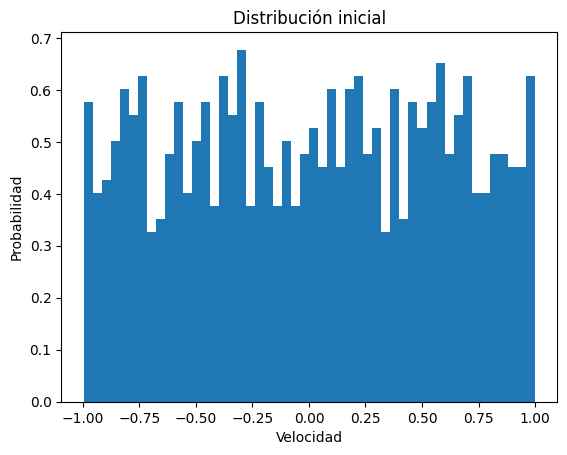

In [4]:
plt.hist(velocities, bins=50, density=True)
plt.title("Distribución inicial")
plt.xlabel("Velocidad")
plt.ylabel("Probabilidad")
plt.show()

In [5]:
def energy(v):
    return 0.5 * m * v**2

In [6]:
def metropolis_step(v, beta):

    i = np.random.randint(0, len(v))

    v_new = v[i] + np.random.uniform(-delta, delta)

    dE = energy(v_new) - energy(v[i])

    if dE < 0 or np.random.rand() < np.exp(-beta * dE):
        v[i] = v_new

    return v

In [7]:
for step in range(steps):
    velocities = metropolis_step(velocities, beta)

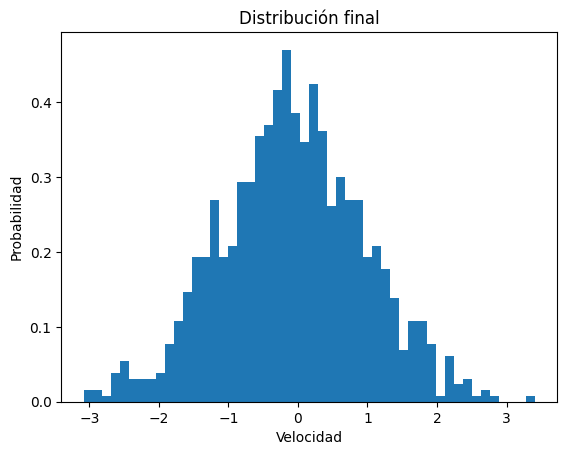

In [8]:
plt.hist(velocities, bins=50, density=True)
plt.title("Distribución final")
plt.xlabel("Velocidad")
plt.ylabel("Probabilidad")
plt.show()

In [9]:
def total_energy(v):
    return np.sum(0.5 * m * v**2)

In [10]:
energies = []

for step in range(steps):

    velocities = metropolis_step(velocities, beta)

    if step > steps*0.2:
        energies.append(total_energy(velocities))

E_avg = np.mean(energies)

print(E_avg)

493.7089076097569


In [11]:
temperatures = np.linspace(0.5, 3.0, 10)

In [12]:
E_avg_list = []

In [13]:
for T in temperatures:

    beta = 1 / T

    # reiniciar velocidades
    velocities = np.random.uniform(-1, 1, N)

    energies = []

    for step in range(steps):

        velocities = metropolis_step(velocities, beta)

        # thermalization
        if step > steps * 0.2:

            energies.append(total_energy(velocities))

    E_avg = np.mean(energies)

    E_avg_list.append(E_avg)

    print("T =", T, " <E> =", E_avg)

T = 0.5  <E> = 257.89702178247296
T = 0.7777777777777778  <E> = 385.4748054219369
T = 1.0555555555555556  <E> = 513.0544088917974
T = 1.3333333333333335  <E> = 617.924299730466
T = 1.6111111111111112  <E> = 709.8594711065386
T = 1.8888888888888888  <E> = 800.8299392381365
T = 2.166666666666667  <E> = 885.5839351891583
T = 2.4444444444444446  <E> = 972.9321332639928
T = 2.7222222222222223  <E> = 1069.879412013021
T = 3.0  <E> = 1139.4280972208292


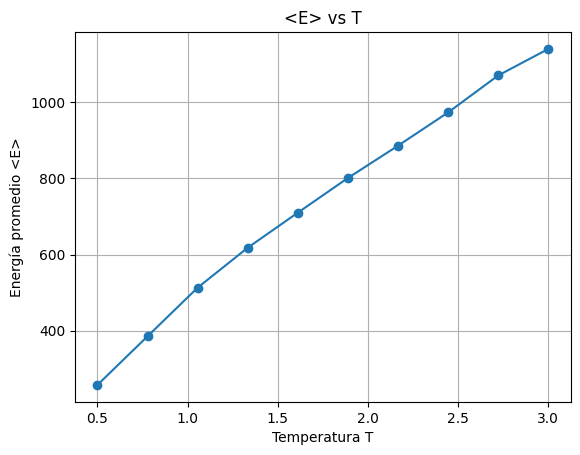

In [14]:
plt.plot(temperatures, E_avg_list, 'o-')

plt.xlabel("Temperatura T")
plt.ylabel("Energía promedio <E>")

plt.title("<E> vs T")

plt.grid()

plt.show()

In [15]:
kB = 1

E_theory = 0.5 * N * kB * temperatures

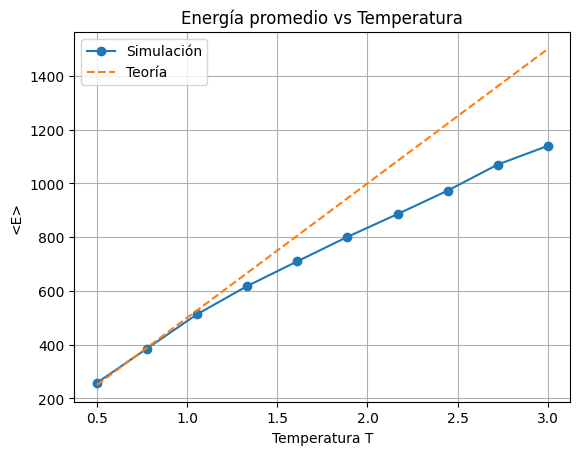

In [16]:
plt.plot(temperatures, E_avg_list, 'o-', label='Simulación')

plt.plot(temperatures, E_theory, '--', label='Teoría')

plt.xlabel("Temperatura T")
plt.ylabel("<E>")

plt.title("Energía promedio vs Temperatura")

plt.legend()

plt.grid()

plt.show()